In [36]:
from pid_functions import *
import matplotlib.pyplot as plt
import time
import numpy as np

# plot error signal

In [37]:
import numpy as np

# use jupyter "magic" command to tell it to embed plot into the notebook
import matplotlib.pyplot as plt
%matplotlib inline

# the following code make plots look better
def plot_prettier(dpi=150, fontsize=11, usetex=False):
    '''
    Make plots look nicer compared to Matplotlib defaults
    Parameters:
        dpi - int, "dots per inch" - controls resolution of PNG images that are produced
                by Matplotlib
        fontsize - int, font size to use overall
        usetex - bool, whether to use LaTeX to render fonds of axes labels
                use False if you don't have LaTeX installed on your system
    '''
    plt.rcParams['figure.dpi']= dpi
    plt.rc("savefig", dpi=dpi)
    plt.rc('font', size=fontsize)
    plt.rc('xtick', direction='in')
    plt.rc('ytick', direction='in')
    plt.rc('xtick.major', pad=5)
    plt.rc('xtick.minor', pad=5)
    plt.rc('ytick.major', pad=5)
    plt.rc('ytick.minor', pad=5)
    plt.rc('lines', dotted_pattern = [2., 2.])
    if usetex:
        plt.rc('text', usetex=usetex)
    else:
        plt.rcParams['mathtext.fontset'] = 'cm'
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

plot_prettier()

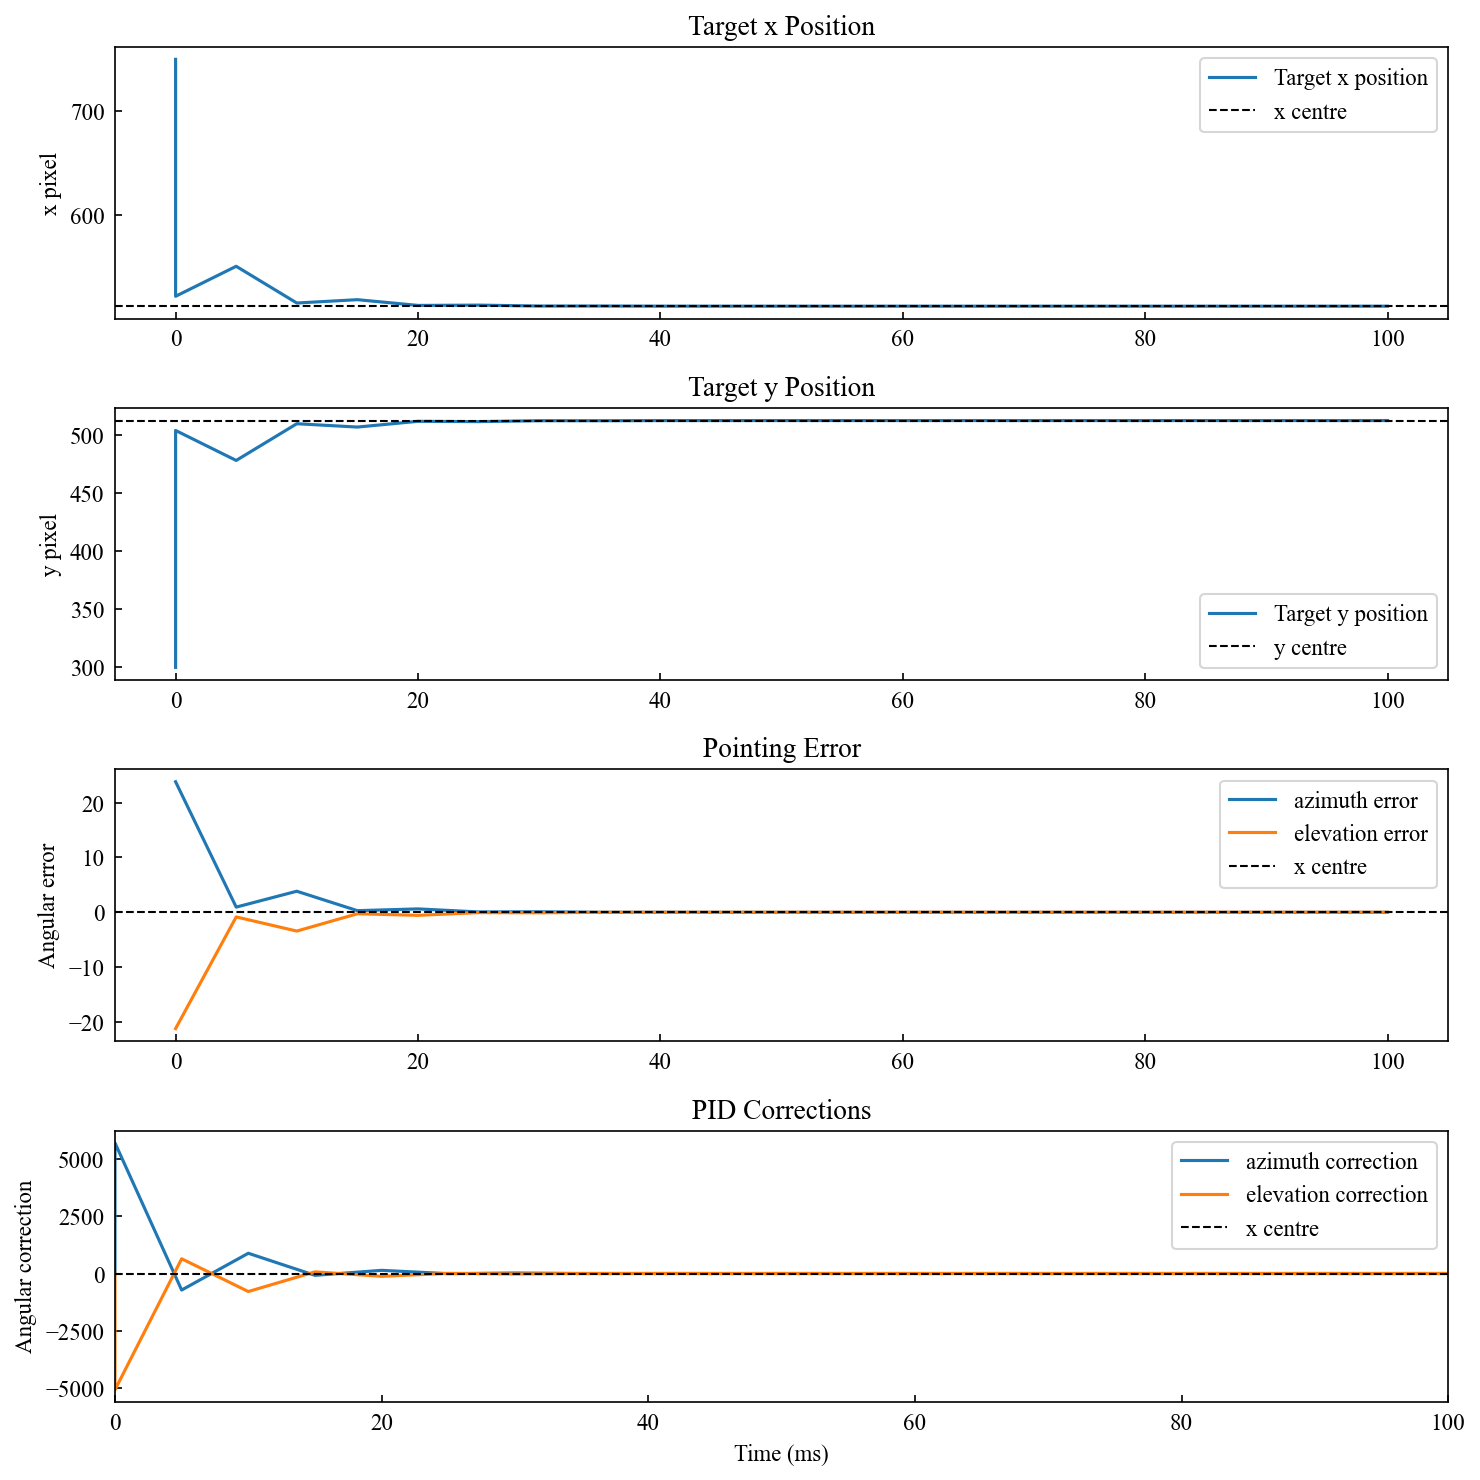

In [67]:
def main():

    # simulation settings
    dt = 5e-3 # s
    simulation_time = 100 / 1000 # ms
    steps = int(simulation_time / dt)

    # camera
    x_centre = 512
    y_centre = 512

    x = 750
    y = 300

    plate_scale = 0.1 # arcseconds per pixel; angle unit here is the same as the angle unit for az/el in graphs
                    # see calculate_pointing_error() in pid_function.py
    camera_rotation = 0.0


    current_az = 135.0
    current_el = 45.0


    az_pid = PIDController(kp=200, ki=10, kd=0.2) 
    el_pid = PIDController(kp=200, ki=10, kd=0.2)


    time_values = [0]

    x_values = [x]
    y_values = [y]

    az_values = [current_az]
    el_values = [current_el]

    az_error, el_error = calculate_pointing_error(
            x=x,
            y=y,
            x_centre=x_centre,
            y_centre=y_centre,
            plate_scale=plate_scale,
            camera_rotation=camera_rotation
        )

    az_error_values = [az_error]
    el_error_values = [el_error]

    az_correction_values = [0]
    el_correction_values = [0]
    min_correction = 0.24751776749652 # arcseconds

    # begin simulation loop
    for i in range(steps+1):
        current_time = i * dt

        (
            new_az,
            new_el,
            error_az,
            error_el,
            az_correction,
            el_correction
        ) = pid_pointing_update(
            x=x,
            y=y,
            x_centre=x_centre,
            y_centre=y_centre,
            current_az=current_az,
            current_el=current_el,
            plate_scale=plate_scale,
            az_pid=az_pid,
            el_pid=el_pid,
            dt=dt,
            camera_rotation=camera_rotation
        )

        if abs(az_correction) < min_correction:
            az_correction = np.sign(az_correction) * min_correction

        if abs(el_correction) < min_correction:
            el_correction = np.sign(el_correction) * min_correction

        current_az = new_az
        current_el = new_el


        response_strength = 0.8

        x -= response_strength * (az_correction / plate_scale) * dt
        y -= response_strength * (el_correction / plate_scale) * dt

      
        time_values.append(current_time)

        x_values.append(x)
        y_values.append(y)

        az_values.append(current_az)
        el_values.append(current_el)

        az_error_values.append(error_az)
        el_error_values.append(error_el)

        az_correction_values.append(az_correction)
        el_correction_values.append(el_correction)

        time.sleep(dt)

    # -----------------------------
    # PLOT GRAPHS

    # convert time from s to ms
    time_values_ms = [1000*t for t in time_values]

    plt.figure(figsize=(10, 10))

    plt.subplot(4, 1, 1)
    plt.plot(time_values_ms, x_values, label="Target x position")
    plt.axhline(x_centre, linestyle="--", label="x centre", c='k', lw=1)
    plt.ylabel("x pixel")
    plt.title("Target x Position")
    plt.legend()

    plt.subplot(4, 1, 2)
    plt.plot(time_values_ms, y_values, label="Target y position")
    plt.axhline(y_centre, linestyle="--", label="y centre", c='k', lw=1)
    plt.ylabel("y pixel")
    plt.title("Target y Position")
    plt.legend()

    plt.subplot(4, 1, 3)
    plt.plot(time_values_ms, az_error_values, label="azimuth error")
    plt.plot(time_values_ms, el_error_values, label="elevation error")
    plt.axhline(y=0, linestyle="--", label="x centre", c='k', lw=1)
    # plt.xlim(left=60, right = 100)
    # plt.ylim(bottom = -0.5, top=0.5)
    plt.ylabel("Angular error")
    plt.title("Pointing Error")
    plt.legend()

    plt.subplot(4, 1, 4)
    plt.plot(time_values_ms, az_correction_values, label="azimuth correction")
    plt.plot(time_values_ms, el_correction_values, label="elevation correction")
    plt.axhline(y=0, linestyle="--", label="x centre", c='k', lw=1)
    plt.xlim(left=0, right=100)
    # plt.ylim(bottom=-0.5, top=0.5)
    plt.xlabel("Time (ms)")
    plt.ylabel("Angular correction")
    plt.title("PID Corrections")
    plt.legend()
    # plt.savefig('pid_sim_plots.png')
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()

In [60]:
# set limit on minimum correction size

# use 0.24751776749652 arcseconds (1.2 microradians)